In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("zomato.csv")

# Show first 5 rows
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [88]:
df.shape

(51717, 17)

In [89]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [90]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [91]:
df.isnull().sum().sort_values(ascending=False)

dish_liked                     28078
rate                            7775
phone                           1208
approx_cost(for two people)      346
rest_type                        227
cuisines                          45
location                          21
listed_in(type)                    0
menu_item                          0
reviews_list                       0
url                                0
address                            0
votes                              0
book_table                         0
online_order                       0
name                               0
listed_in(city)                    0
dtype: int64

In [92]:
df['dish_liked'] = df['dish_liked'].fillna('Not Mentioned')

In [93]:
df.drop('phone', axis=1, inplace=True)

In [94]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [95]:
df['rate'] = df['rate'].str.replace('/5', '', regex=False)

df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [96]:
df['rate'] = df['rate'].fillna(df['rate'].median())

In [97]:
df['location'] = df['location'].fillna(df['location'].mode()[0])

In [98]:
df['rest_type'] = df['rest_type'].fillna(df['rest_type'].mode()[0])

In [99]:
df['cuisines'] = df['cuisines'].fillna(df['cuisines'].mode()[0])

In [100]:
# Remove commas
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')

# Convert to numeric
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

# Fill missing values with median
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna(
    df['approx_cost(for two people)'].median()
)

In [101]:
df.isnull().sum()

url                            0
address                        0
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
dish_liked                     0
cuisines                       0
approx_cost(for two people)    0
reviews_list                   0
menu_item                      0
listed_in(type)                0
listed_in(city)                0
dtype: int64

In [102]:
#Create Low Performing Restaurants Logic

df['customer_loss_risk'] = np.where(
    (df['rate'] < 3.5) &
    (df['votes'] < 100),
    'High Risk',
    'Low Risk'
)

In [103]:
df[['name', 'rate', 'votes', 'customer_loss_risk']].head(10)

,name,rate,votes,customer_loss_risk
0,Jalsa,4.1,775,Low Risk
1,Spice Elephant,4.1,787,Low Risk
2,San Churro Cafe,3.8,918,Low Risk
3,Addhuri Udupi Bhojana,3.7,88,Low Risk
4,Grand Village,3.8,166,Low Risk
5,Timepass Dinner,3.8,286,Low Risk
6,Rosewood International Hotel - Bar & Restaurant,3.6,8,Low Risk
7,Onesta,4.6,2556,Low Risk
8,Penthouse Cafe,4.0,324,Low Risk
9,Smacznego,4.2,504,Low Risk


In [104]:
df['customer_loss_risk'].value_counts()

customer_loss_risk
Low Risk     41962
High Risk     9755
Name: count, dtype: int64

In [105]:


df.groupby('book_table')['votes'].mean()

book_table
No      160.690664
Yes    1147.129788
Name: votes, dtype: float64

In [106]:


df.groupby('online_order')['votes'].mean()

online_order
No     250.31594
Yes    307.02319
Name: votes, dtype: float64

In [107]:
df['restaurant_popularity'] = np.where(
    df['votes'] > 500,
    'Popular',
    'Less Popular'
)

In [108]:
df[['name', 'votes', 'restaurant_popularity']].head()

,name,votes,restaurant_popularity
0,Jalsa,775,Popular
1,Spice Elephant,787,Popular
2,San Churro Cafe,918,Popular
3,Addhuri Udupi Bhojana,88,Less Popular
4,Grand Village,166,Less Popular


Exploratory Data Analysis (EDA)


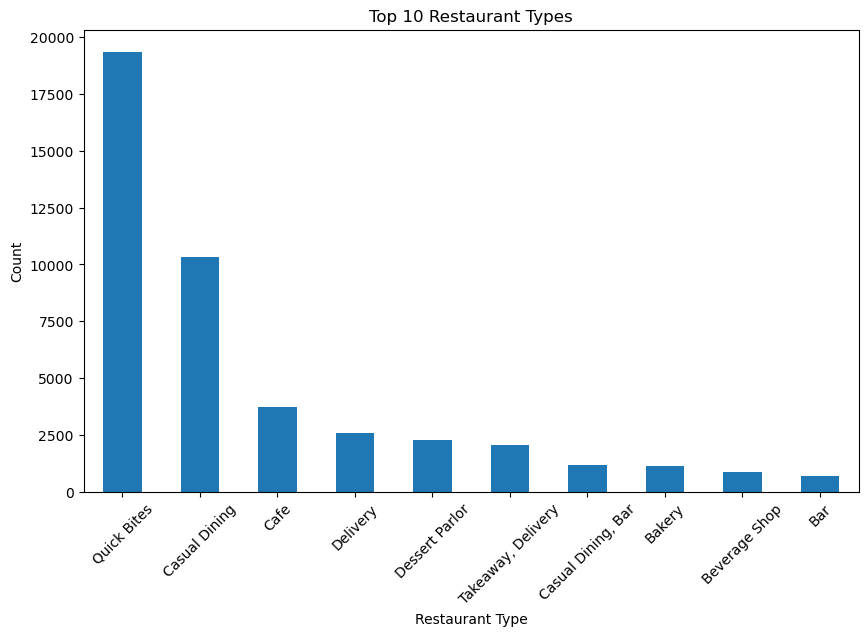

In [109]:
#Top Restaurant Types
# Which restaurant types are most common?

plt.figure(figsize=(10,6))

df['rest_type'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Restaurant Types")
plt.xlabel("Restaurant Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

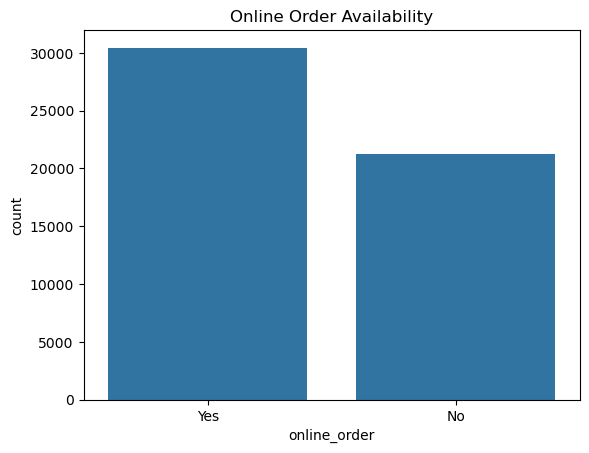

In [110]:
# Online Order Analysis
sns.countplot(x='online_order', data=df)

plt.title("Online Order Availability")

plt.show()

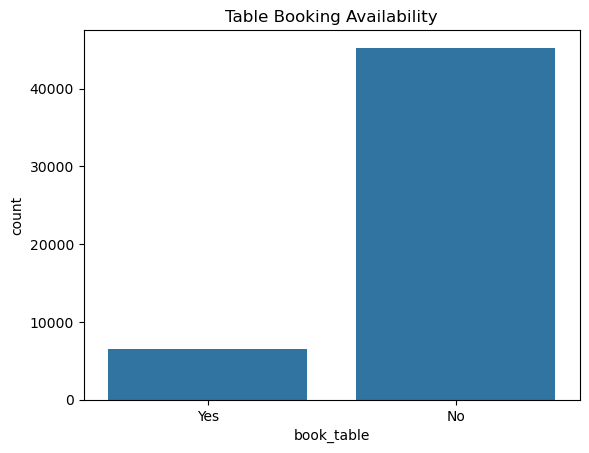

In [111]:
# Table Booking Analysis
sns.countplot(x='book_table', data=df)

plt.title("Table Booking Availability")

plt.show()

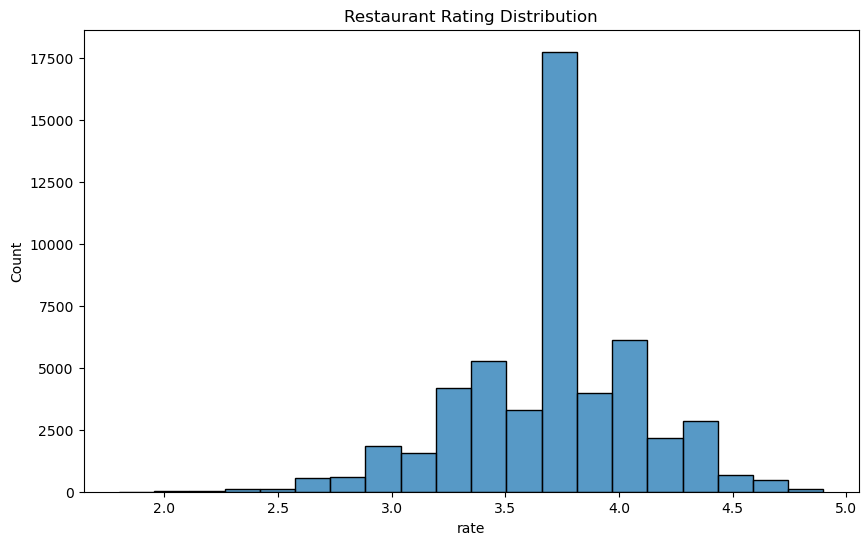

In [112]:
# Rating Distribution
# How are restaurant ratings distributed?

plt.figure(figsize=(10,6))

sns.histplot(df['rate'], bins=20)

plt.title("Restaurant Rating Distribution")

plt.show()

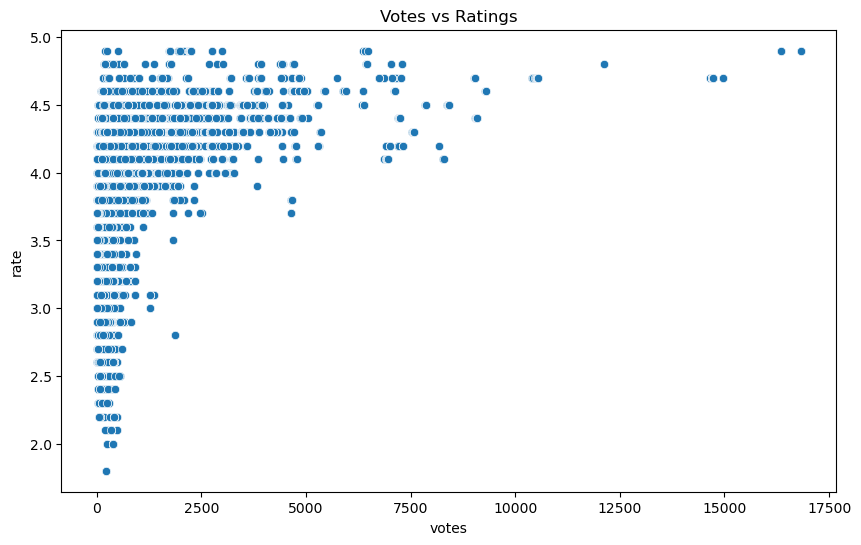

In [113]:
# Votes vs Rating
plt.figure(figsize=(10,6))

sns.scatterplot(x='votes', y='rate', data=df)

plt.title("Votes vs Ratings")

plt.show()

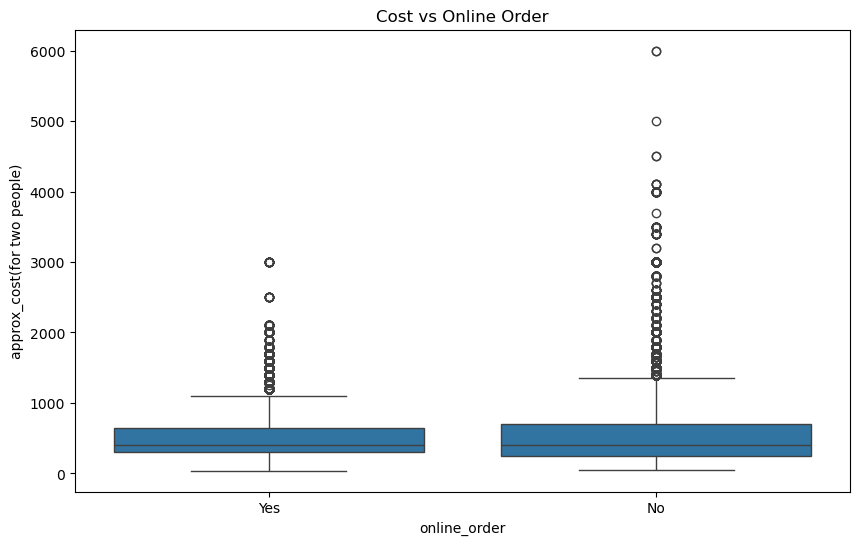

In [114]:
# Cost Analysis

plt.figure(figsize=(10,6))

sns.boxplot(
    x='online_order',
    y='approx_cost(for two people)',
    data=df
)

plt.title("Cost vs Online Order")

plt.show()

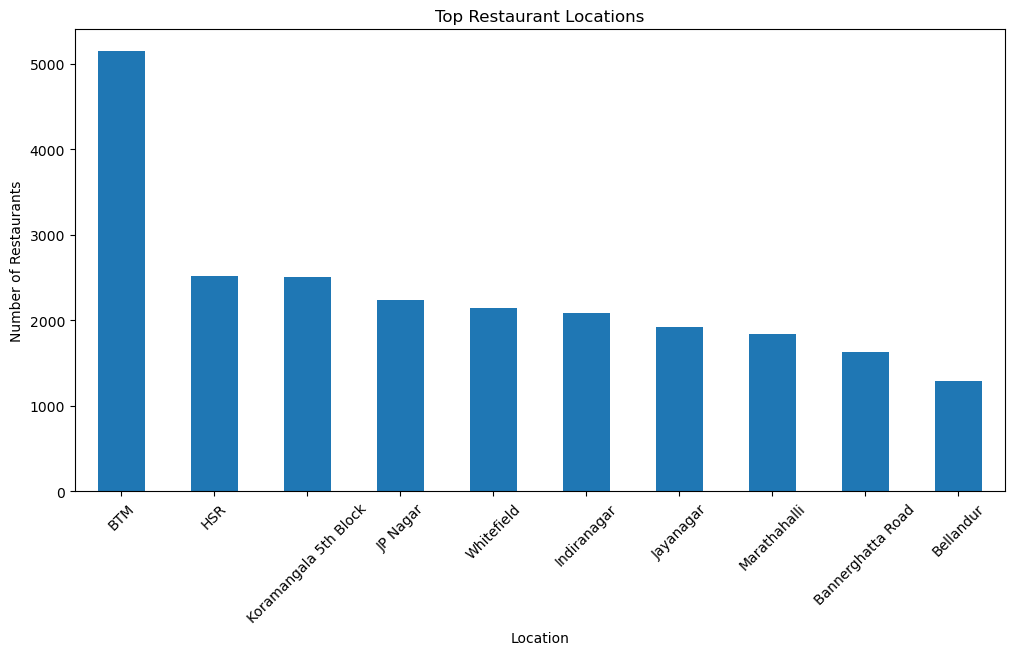

In [115]:
# Top Locations

plt.figure(figsize=(12,6))

df['location'].value_counts().head(10).plot(kind='bar')

plt.title("Top Restaurant Locations")

plt.xlabel("Location")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

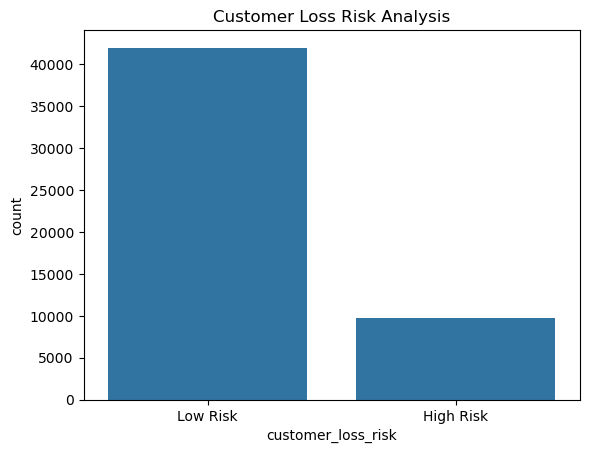

In [116]:
# High Risk Restaurants

sns.countplot(x='customer_loss_risk', data=df)

plt.title("Customer Loss Risk Analysis")

plt.show()

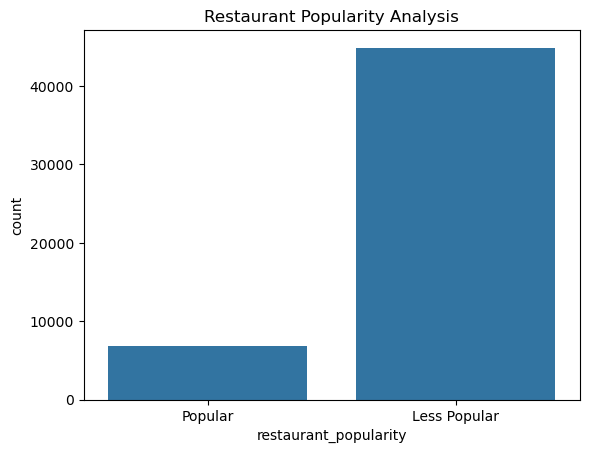

In [117]:
# Popular vs Less Popular Restaurants

sns.countplot(x='restaurant_popularity', data=df)

plt.title("Restaurant Popularity Analysis")

plt.show()

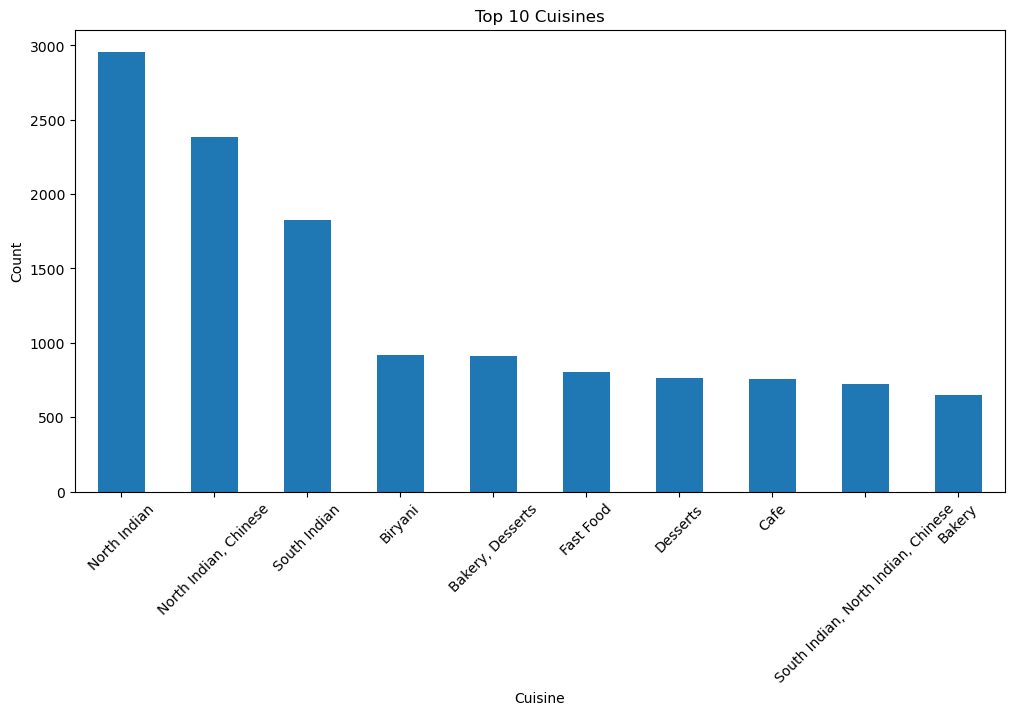

In [118]:
# Top Cuisines

top_cuisines = df['cuisines'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_cuisines.plot(kind='bar')

plt.title("Top 10 Cuisines")

plt.xlabel("Cuisine")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

Advanced Business Insights & KPI Analysis

In [119]:
# Correlation Analysis
numeric_df = df[['rate', 'votes', 'approx_cost(for two people)']]

correlation = numeric_df.corr()

correlation

,rate,votes,approx_cost(for two people)
rate,1.000000,0.427443,0.364812
votes,0.427443,1.000000,0.380992
approx_cost(for two people),0.364812,0.380992,1.000000


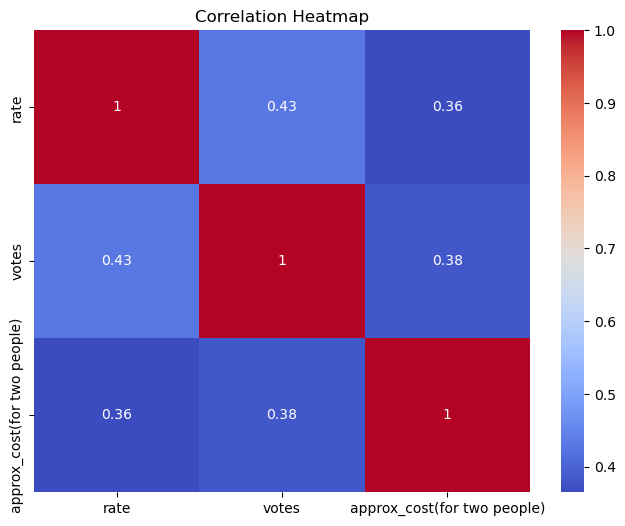

In [120]:
plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

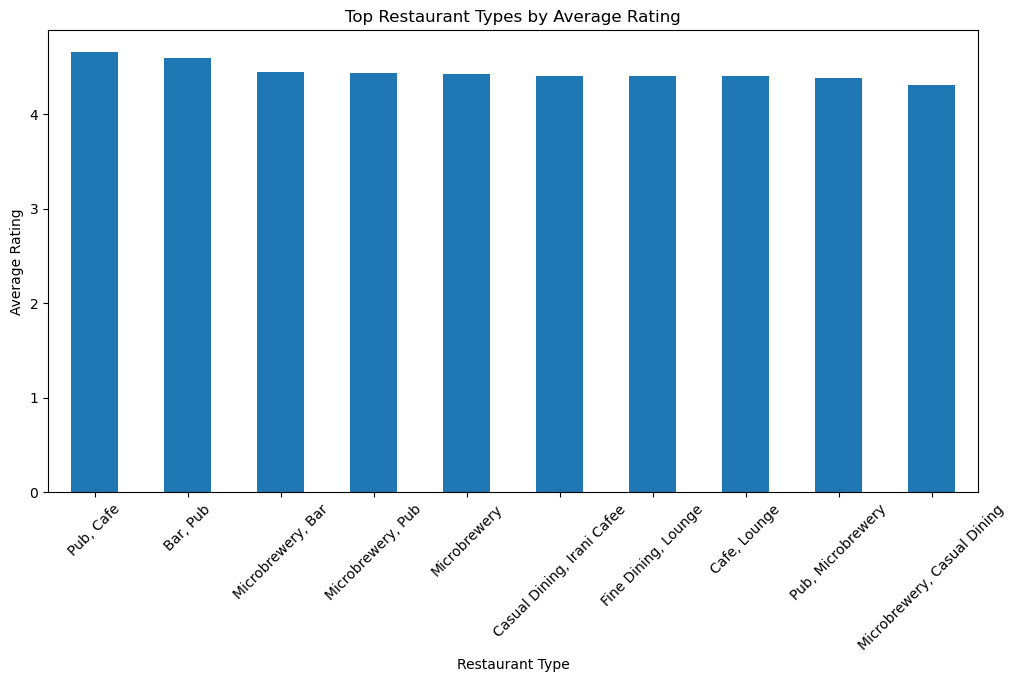

In [121]:
rest_rating = df.groupby('rest_type')['rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

rest_rating.plot(kind='bar')

plt.title("Top Restaurant Types by Average Rating")

plt.xlabel("Restaurant Type")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

In [122]:
# Online Order Impact on Ratings

online_rating = df.groupby('online_order')['rate'].mean()

online_rating

online_order
No     3.672181
Yes    3.720053
Name: rate, dtype: float64

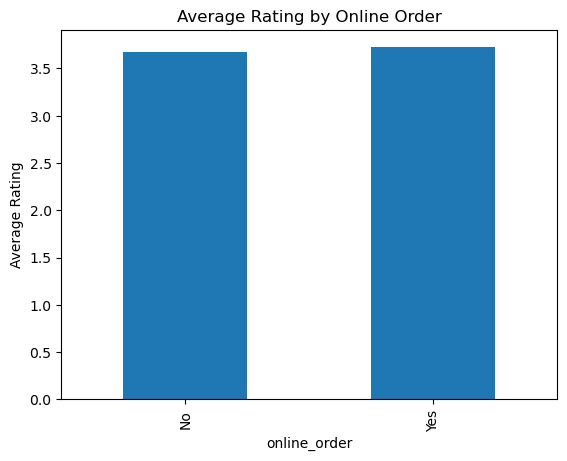

In [123]:
online_rating.plot(kind='bar')

plt.title("Average Rating by Online Order")

plt.ylabel("Average Rating")

plt.show()

In [124]:
# Table Booking Impact

table_votes = df.groupby('book_table')['votes'].mean()

table_votes

book_table
No      160.690664
Yes    1147.129788
Name: votes, dtype: float64

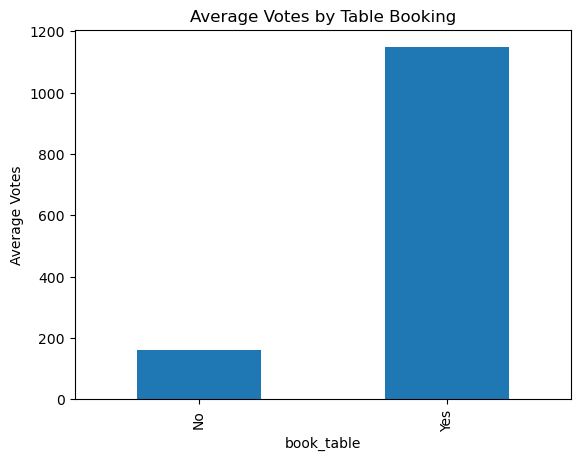

In [125]:
table_votes.plot(kind='bar')

plt.title("Average Votes by Table Booking")

plt.ylabel("Average Votes")

plt.show()

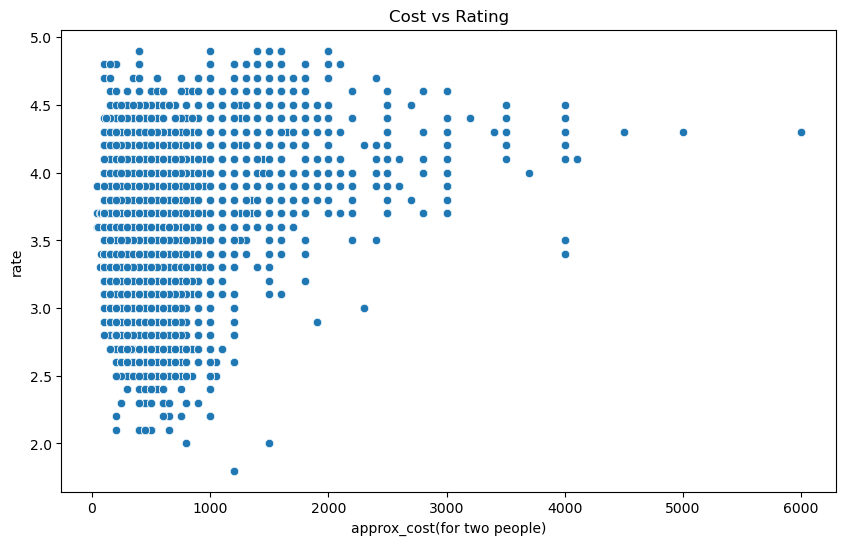

In [126]:
#Cost vs Rating Analysis
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='approx_cost(for two people)',
    y='rate',
    data=df
)

plt.title("Cost vs Rating")

plt.show()


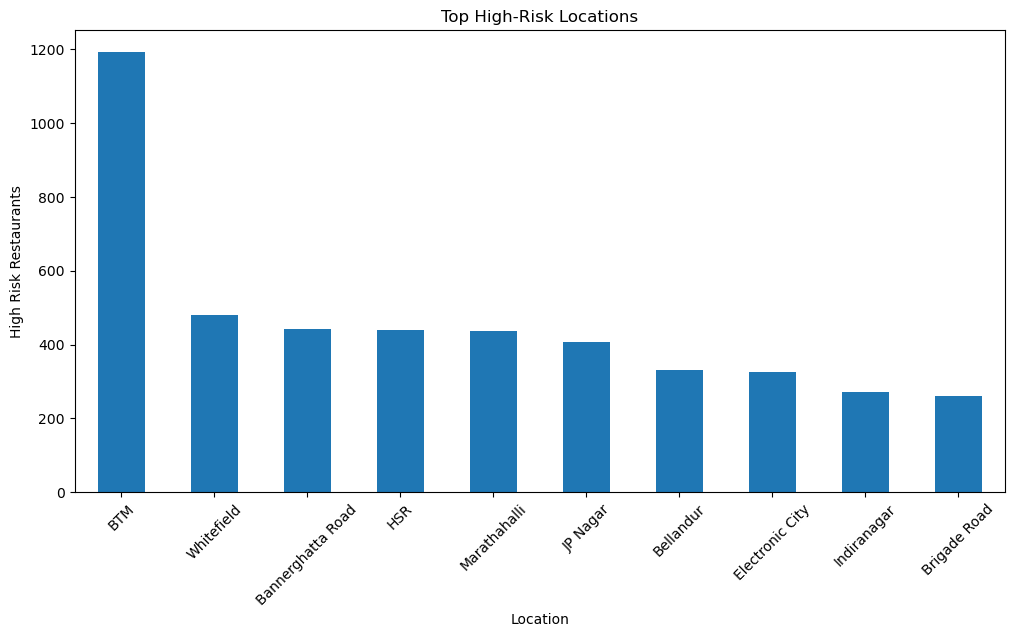

In [127]:
high_risk = df[df['customer_loss_risk'] == 'High Risk']

risk_locations = high_risk['location'].value_counts().head(10)

plt.figure(figsize=(12,6))

risk_locations.plot(kind='bar')

plt.title("Top High-Risk Locations")

plt.xlabel("Location")
plt.ylabel("High Risk Restaurants")

plt.xticks(rotation=45)

plt.show()

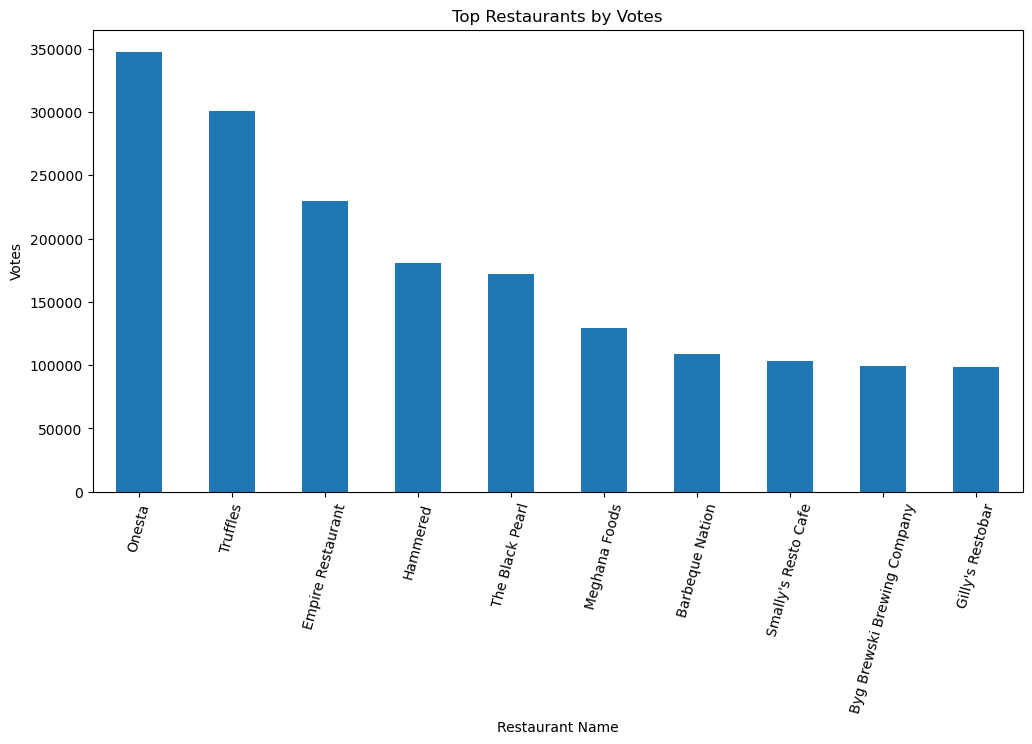

In [128]:
top_restaurants = df.groupby('name')['votes'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_restaurants.plot(kind='bar')

plt.title("Top Restaurants by Votes")

plt.xlabel("Restaurant Name")
plt.ylabel("Votes")

plt.xticks(rotation=75)

plt.show()

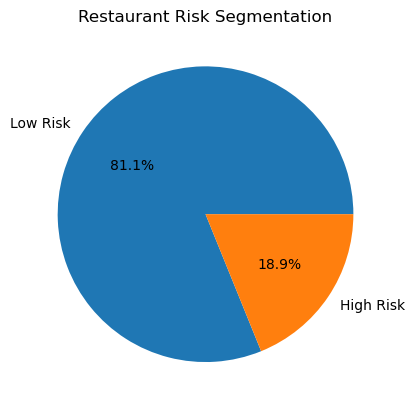

In [129]:
risk_counts = df['customer_loss_risk'].value_counts()

risk_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title("Restaurant Risk Segmentation")

plt.ylabel("")

plt.show()

In [130]:
df.to_csv("zomato_cleaned.csv", index=False)

In [135]:
import pandas as pd

from sqlalchemy import create_engine
from sqlalchemy.types import Text
from sqlalchemy.dialects.mysql import LONGTEXT

# MySQL connection
username = "root"
password = "1234"
host = "localhost"
port = "3306"
database = "zomato_analysis"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

# Upload dataframe
df.to_sql(
    name='zomato',
    con=engine,
    if_exists='replace',
    index=False,
    chunksize=10000,

    dtype={
        'reviews_list': LONGTEXT,
        'menu_item': LONGTEXT,
        'dish_liked': LONGTEXT
    }
)

print("Data Imported Successfully")



Data Imported Successfully
